## 1. Import Library & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Palet warna
BLUE   = '#2563EB'
GREEN  = '#16A34A'
RED    = '#DC2626'
AMBER  = '#D97706'
PURPLE = '#7C3AED'
GRAY   = '#6B7280'
LIGHT  = '#F8FAFC'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.facecolor'   : LIGHT,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.color'       : '#CBD5E1'
})

print('Library berhasil diimport.')

Library berhasil diimport.


---
## 2. Load Dataset & Inspeksi Awal

In [2]:
df = pd.read_csv('hotel_bookings.csv')

print(f'Jumlah baris  : {len(df):,}')
print(f'Jumlah kolom  : {len(df.columns)}')
print(f'\nTipe data:')
print(df.dtypes)

Jumlah baris  : 119,390
Jumlah kolom  : 32

Tipe data:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type         

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


---
## 3. EDA untuk Anomaly Detection

### Identifikasi Kandidat Anomali

In [5]:
print('=== KANDIDAT ANOMALI DI DATASET ===')
print(f'ADR negatif (tidak logis)     : {(df["adr"] < 0).sum()} baris')
print(f'ADR > 1000 EUR (ekstrem)      : {(df["adr"] > 1000).sum()} baris')
print(f'adults = 0 (tanpa tamu dewasa): {(df["adults"] == 0).sum()} baris')
print(f'lead_time > 500 hari          : {(df["lead_time"] > 500).sum()} baris')
print(f'stays_in_week_nights > 30     : {(df["stays_in_week_nights"] > 30).sum()} baris')
print(f'stays_in_weekend_nights > 10  : {(df["stays_in_weekend_nights"] > 10).sum()} baris')
print(f'booking_changes > 10          : {(df["booking_changes"] > 10).sum()} baris')
print(f'previous_cancellations > 10   : {(df["previous_cancellations"] > 10).sum()} baris')

=== KANDIDAT ANOMALI DI DATASET ===
ADR negatif (tidak logis)     : 1 baris
ADR > 1000 EUR (ekstrem)      : 1 baris
adults = 0 (tanpa tamu dewasa): 403 baris
lead_time > 500 hari          : 481 baris
stays_in_week_nights > 30     : 9 baris
stays_in_weekend_nights > 10  : 15 baris
booking_changes > 10          : 24 baris
previous_cancellations > 10   : 180 baris


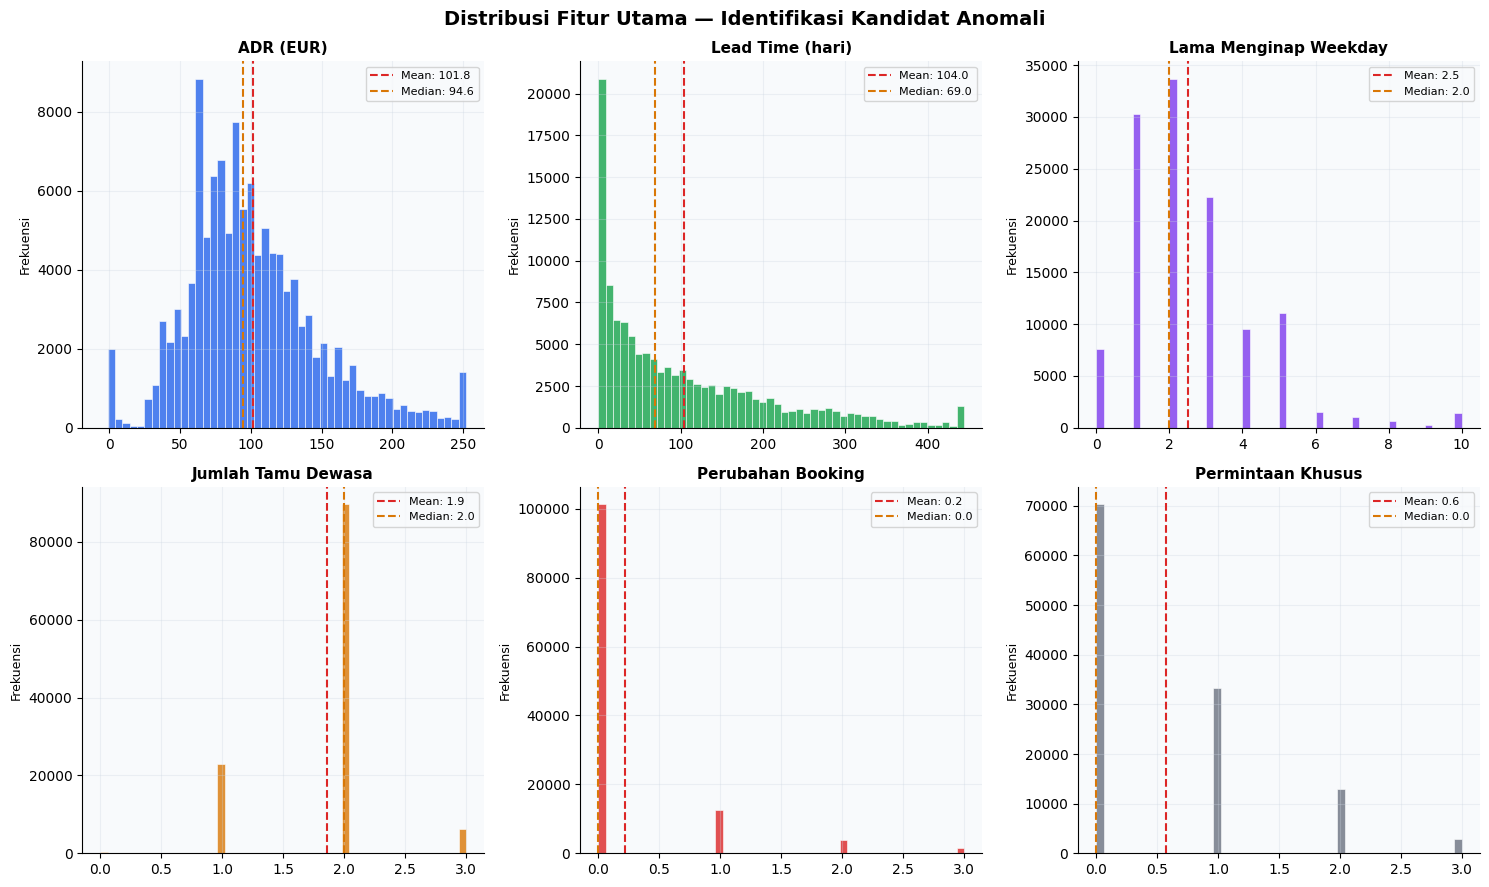

Gambar disimpan: eda_distribusi_fitur.png


In [6]:
# Visualisasi distribusi fitur kandidat anomali
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribusi Fitur Utama — Identifikasi Kandidat Anomali',
             fontsize=14, fontweight='bold')

features = [
    ('adr',                    'ADR (EUR)',            BLUE),
    ('lead_time',              'Lead Time (hari)',     GREEN),
    ('stays_in_week_nights',   'Lama Menginap Weekday', PURPLE),
    ('adults',                 'Jumlah Tamu Dewasa',   AMBER),
    ('booking_changes',        'Perubahan Booking',    RED),
    ('total_of_special_requests', 'Permintaan Khusus', GRAY),
]

for ax, (col, label, color) in zip(axes.flatten(), features):
    data = df[col].clip(upper=df[col].quantile(0.99))  # clip untuk visualisasi
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(),   color=RED,   linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color=AMBER, linestyle='--', linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: eda_distribusi_fitur.png')

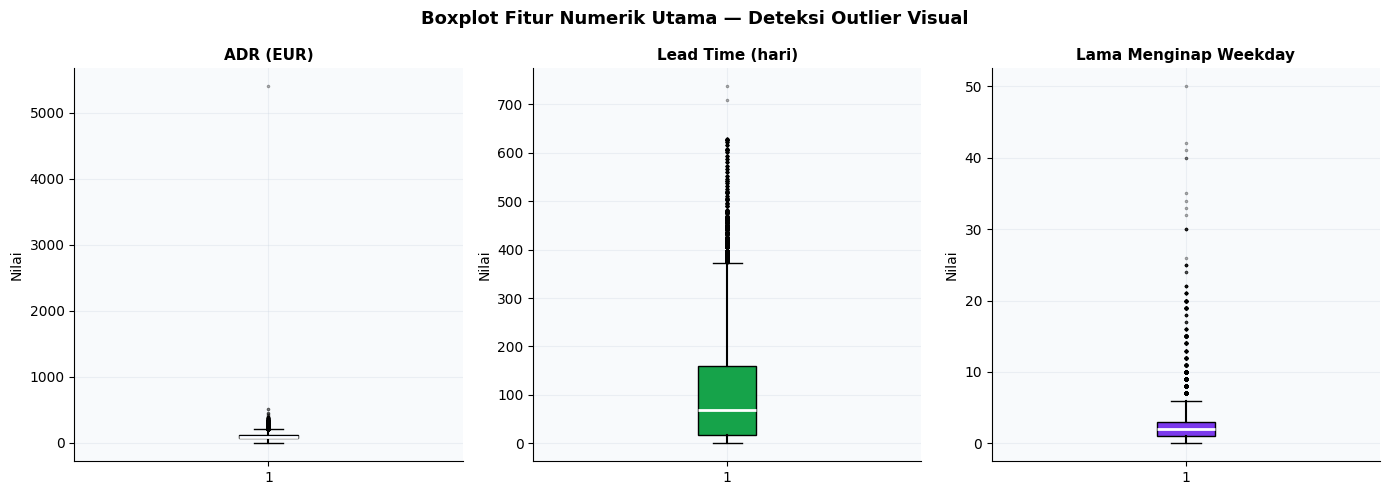

Gambar disimpan: eda_boxplot_outlier.png


In [7]:
# Boxplot untuk deteksi outlier secara visual
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Boxplot Fitur Numerik Utama — Deteksi Outlier Visual',
             fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, features[:3]):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4, color=RED))
    bp['boxes'][0].set_facecolor(color)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai', fontsize=10)

plt.tight_layout()
plt.savefig('eda_boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: eda_boxplot_outlier.png')

### Missing Values

In [8]:
mv     = df.isnull().sum()
mv     = mv[mv > 0].sort_values(ascending=False)
mv_pct = (mv / len(df) * 100).round(2)

mv_df = pd.DataFrame({
    'Jumlah Missing' : mv.values,
    'Persentase (%)'  : mv_pct.values,
    'Strategi'        : [
        'DROP kolom — 94.3% kosong, tidak informatif',
        'Imputasi dengan "Unknown" — booking tanpa agen tetap valid',
        'Imputasi dengan modus ("PRT") — mayoritas tamu dari Portugal',
        'Imputasi dengan 0 — asumsi tidak ada anak'
    ]
}, index=mv.index)

print('Missing Values per Kolom:')
print(mv_df.to_string())

Missing Values per Kolom:
          Jumlah Missing  Persentase (%)                                                      Strategi
company           112593           94.31                   DROP kolom — 94.3% kosong, tidak informatif
agent              16340           13.69    Imputasi dengan "Unknown" — booking tanpa agen tetap valid
country              488            0.41  Imputasi dengan modus ("PRT") — mayoritas tamu dari Portugal
children               4            0.00                     Imputasi dengan 0 — asumsi tidak ada anak


---
## 4. Data Preprocessing Pipeline

### Step 1 — Data Cleaning

In [9]:
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

# Drop kolom tidak berguna / data leakage
cols_to_drop = [
    'company',                  # 94.3% missing
    'reservation_status',       # data leakage — diketahui setelah booking selesai
    'reservation_status_date',  # data leakage
    'arrival_date_year',        # tidak relevan untuk deteksi anomali pola
    'arrival_date_week_number', # redundan dengan bulan
    'arrival_date_day_of_month',# terlalu granular
]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Setelah drop kolom: {df_clean.shape}')

# Hapus duplikat 
n_dup = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f'Baris duplikat dihapus: {n_dup}')

print(f'\nShape setelah cleaning: {df_clean.shape}')

Shape awal: (119390, 32)
Setelah drop kolom: (119390, 26)
Baris duplikat dihapus: 32468

Shape setelah cleaning: (86922, 26)


### Step 2 — Handling Missing Values

In [10]:
# Imputasi agent → 'Unknown'
df_clean['agent'] = df_clean['agent'].fillna('Unknown').astype(str)

# Imputasi country → modus
country_mode = df_clean['country'].mode()[0]
df_clean['country'] = df_clean['country'].fillna(country_mode)

# Imputasi children → 0
df_clean['children'] = df_clean['children'].fillna(0).astype(int)

# Verifikasi
remaining_mv = df_clean.isnull().sum()
print('Missing values setelah imputasi:')
print(remaining_mv[remaining_mv > 0] if remaining_mv.sum() > 0 else '  Tidak ada missing value tersisa ✓')

Missing values setelah imputasi:
  Tidak ada missing value tersisa ✓


### Step 3 — Feature Engineering

In [11]:
# total_nights: total durasi menginap
df_clean['total_nights'] = (
    df_clean['stays_in_week_nights'] + df_clean['stays_in_weekend_nights']
)

# total_guests: total jumlah tamu
df_clean['total_guests'] = (
    df_clean['adults'] + df_clean['children'] + df_clean['babies']
)

# room_mismatch: 1 jika kamar yang diberikan berbeda dari yang dipesan
df_clean['room_mismatch'] = (
    df_clean['reserved_room_type'] != df_clean['assigned_room_type']
).astype(int)

# arrival_season: musim kedatangan
season_map = {
    'December': 'Winter', 'January': 'Winter',  'February': 'Winter',
    'March'   : 'Spring', 'April'  : 'Spring',  'May'     : 'Spring',
    'June'    : 'Summer', 'July'   : 'Summer',  'August'  : 'Summer',
    'September':'Fall',   'October': 'Fall',    'November': 'Fall'
}
df_clean['arrival_season'] = df_clean['arrival_date_month'].map(season_map)

# adr_per_night: ADR relatif terhadap durasi (deteksi harga aneh)
df_clean['adr_per_guest'] = df_clean.apply(
    lambda r: r['adr'] / r['total_guests'] if r['total_guests'] > 0 else 0, axis=1
)

print('Fitur baru yang dibuat:')
new_features = ['total_nights','total_guests','room_mismatch','arrival_season','adr_per_guest']
print(df_clean[new_features].describe().round(2))

Fitur baru yang dibuat:
       total_nights  total_guests  room_mismatch  adr_per_guest
count      86922.00      86922.00       86922.00       86922.00
mean           3.64          2.03           0.15          55.52
std            2.76          0.80           0.36          29.84
min            0.00          0.00           0.00          -3.19
25%            2.00          2.00           0.00          37.83
50%            3.00          2.00           0.00          50.00
75%            5.00          2.00           0.00          67.42
max           69.00         55.00           1.00        2700.00


### Step 4 — Feature Selection

In [12]:
# Fitur numerik yang digunakan
numerical_features = [
    'lead_time',                   # jarak pemesanan — anomali jika terlalu ekstrem
    'adr',                         # harga kamar — anomali jika negatif atau ekstrem tinggi
    'total_nights',                # durasi menginap — anomali jika sangat panjang
    'total_guests',                # jumlah tamu — anomali jika 0
    'adr_per_guest',               # harga per tamu — deteksi kombinasi aneh
    'total_of_special_requests',   # permintaan khusus
    'booking_changes',             # perubahan booking — anomali jika sangat banyak
    'previous_cancellations',      # riwayat batal
    'days_in_waiting_list',        # lama tunggu
    'required_car_parking_spaces', # kebutuhan parkir
    'is_repeated_guest',           # tamu lama
    'room_mismatch',               # ketidakcocokan kamar
]

# Fitur kategorikal yang digunakan
categorical_features = [
    'hotel',
    'market_segment',
    'deposit_type',
    'customer_type',
    'meal',
    'arrival_season',
]

# Fitur yang di-drop 
dropped_features = {
    'is_canceled'              : 'Bukan fitur pola booking — label hasil akhir',
    'agent'                    : 'Kardinalitas terlalu tinggi setelah imputasi',
    'country'                  : 'Kardinalitas sangat tinggi (177 negara)',
    'stays_in_week_nights'     : 'Sudah terwakili oleh total_nights',
    'stays_in_weekend_nights'  : 'Sudah terwakili oleh total_nights',
    'adults'                   : 'Sudah terwakili oleh total_guests',
    'children'                 : 'Sudah terwakili oleh total_guests',
    'babies'                   : 'Sudah terwakili oleh total_guests',
    'reserved_room_type'       : 'Sudah diwakili room_mismatch',
    'assigned_room_type'       : 'Sudah diwakili room_mismatch',
    'distribution_channel'     : 'Berkorelasi tinggi dengan market_segment',
    'arrival_date_month'       : 'Sudah diwakili arrival_season',
    'previous_bookings_not_canceled': 'Korelasi rendah dengan pola anomali',
}

print(f'Fitur numerik  : {len(numerical_features)}')
print(f'Fitur kategorikal: {len(categorical_features)}')
print(f'Fitur di-drop  : {len(dropped_features)}')
print(f'\nFitur yang di-drop:')
for k, v in dropped_features.items():
    print(f'  {k:40s} → {v}')

Fitur numerik  : 12
Fitur kategorikal: 6
Fitur di-drop  : 13

Fitur yang di-drop:
  is_canceled                              → Bukan fitur pola booking — label hasil akhir
  agent                                    → Kardinalitas terlalu tinggi setelah imputasi
  country                                  → Kardinalitas sangat tinggi (177 negara)
  stays_in_week_nights                     → Sudah terwakili oleh total_nights
  stays_in_weekend_nights                  → Sudah terwakili oleh total_nights
  adults                                   → Sudah terwakili oleh total_guests
  children                                 → Sudah terwakili oleh total_guests
  babies                                   → Sudah terwakili oleh total_guests
  reserved_room_type                       → Sudah diwakili room_mismatch
  assigned_room_type                       → Sudah diwakili room_mismatch
  distribution_channel                     → Berkorelasi tinggi dengan market_segment
  arrival_date_month    

### Step 5 — Encoding Fitur Kategorikal

In [13]:
df_model = df_clean[numerical_features + categorical_features].copy()
print(f'Shape sebelum encoding: {df_model.shape}')

# One-Hot Encoding untuk fitur kategorikal
# drop_first=True untuk menghindari multikolinearitas (dummy variable trap)
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

print(f'Shape setelah One-Hot Encoding: {df_encoded.shape}')
print(f'\nDaftar kolom setelah encoding:')
print(list(df_encoded.columns))

Shape sebelum encoding: (86922, 18)
Shape setelah One-Hot Encoding: (86922, 32)

Daftar kolom setelah encoding:
['lead_time', 'adr', 'total_nights', 'total_guests', 'adr_per_guest', 'total_of_special_requests', 'booking_changes', 'previous_cancellations', 'days_in_waiting_list', 'required_car_parking_spaces', 'is_repeated_guest', 'room_mismatch', 'hotel_Resort Hotel', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'arrival_season_Spring', 'arrival_season_Summer', 'arrival_season_Winter']


### Step 6 — Feature Scaling (StandardScaler)

**Scaling wajib dilakukan** untuk Anomaly Detection karena algoritma seperti Isolation Forest, LOF, dan One-Class SVM berbasis perhitungan jarak. Tanpa scaling, fitur dengan skala besar (seperti `lead_time` 0–737) akan mendominasi dan fitur lain tidak berpengaruh.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print(f'Shape setelah scaling: {df_scaled.shape}')
print(f'\nVerifikasi scaling (mean ≈ 0, std ≈ 1):')
check = pd.DataFrame({
    'Mean (seharusnya ≈ 0)': df_scaled[numerical_features].mean().round(4),
    'Std  (seharusnya ≈ 1)': df_scaled[numerical_features].std().round(4)
})
print(check)

Shape setelah scaling: (86922, 32)

Verifikasi scaling (mean ≈ 0, std ≈ 1):
                             Mean (seharusnya ≈ 0)  Std  (seharusnya ≈ 1)
lead_time                                      0.0                    1.0
adr                                           -0.0                    1.0
total_nights                                   0.0                    1.0
total_guests                                  -0.0                    1.0
adr_per_guest                                 -0.0                    1.0
total_of_special_requests                     -0.0                    1.0
booking_changes                                0.0                    1.0
previous_cancellations                         0.0                    1.0
days_in_waiting_list                          -0.0                    1.0
required_car_parking_spaces                   -0.0                    1.0
is_repeated_guest                              0.0                    1.0
room_mismatch                       

### Step 7 — Train-Test Split

In [15]:
# Anomaly detection bersifat unsupervised — tidak ada label y
# Train-test split tetap dilakukan untuk evaluasi model nantinya
X_train, X_test = train_test_split(
    df_scaled,
    test_size   = 0.2,       # 80% train, 20% test
    random_state= 42,        # random_state tetap untuk reproducibility
    shuffle     = True
)

print('=== HASIL TRAIN-TEST SPLIT ===')
print(f'Total data     : {len(df_scaled):,} baris')
print(f'Training set   : {len(X_train):,} baris ({len(X_train)/len(df_scaled)*100:.0f}%)')
print(f'Test set       : {len(X_test):,} baris ({len(X_test)/len(df_scaled)*100:.0f}%)')
print(f'Jumlah fitur   : {X_train.shape[1]}')
print(f'random_state   : 42 (tetap untuk reproducibility)')

=== HASIL TRAIN-TEST SPLIT ===
Total data     : 86,922 baris
Training set   : 69,537 baris (80%)
Test set       : 17,385 baris (20%)
Jumlah fitur   : 32
random_state   : 42 (tetap untuk reproducibility)


---
## 5. Preview Anomali — Uji Cepat Isolation Forest

Sebagai preview awal, dijalankan Isolation Forest sederhana untuk melihat berapa banyak anomali yang terdeteksi. 

In [16]:
# Isolation Forest dengan contamination 1% (estimasi awal proporsi anomali)
iso_forest = IsolationForest(
    n_estimators  = 100,
    contamination = 0.01,   # estimasi 1% data adalah anomali
    random_state  = 42
)

# Fit pada training set
iso_forest.fit(X_train)

# Prediksi pada seluruh data (1 = normal, -1 = anomali)
y_pred = iso_forest.predict(df_scaled)
anomaly_scores = iso_forest.decision_function(df_scaled)

n_anomaly = (y_pred == -1).sum()
n_normal  = (y_pred ==  1).sum()

print('=== HASIL DETEKSI AWAL (Isolation Forest) ===')
print(f'Total data    : {len(y_pred):,}')
print(f'Normal (1)    : {n_normal:,} ({n_normal/len(y_pred)*100:.1f}%)')
print(f'Anomali (-1)  : {n_anomaly:,} ({n_anomaly/len(y_pred)*100:.1f}%)')

=== HASIL DETEKSI AWAL (Isolation Forest) ===
Total data    : 86,922
Normal (1)    : 86,050 (99.0%)
Anomali (-1)  : 872 (1.0%)


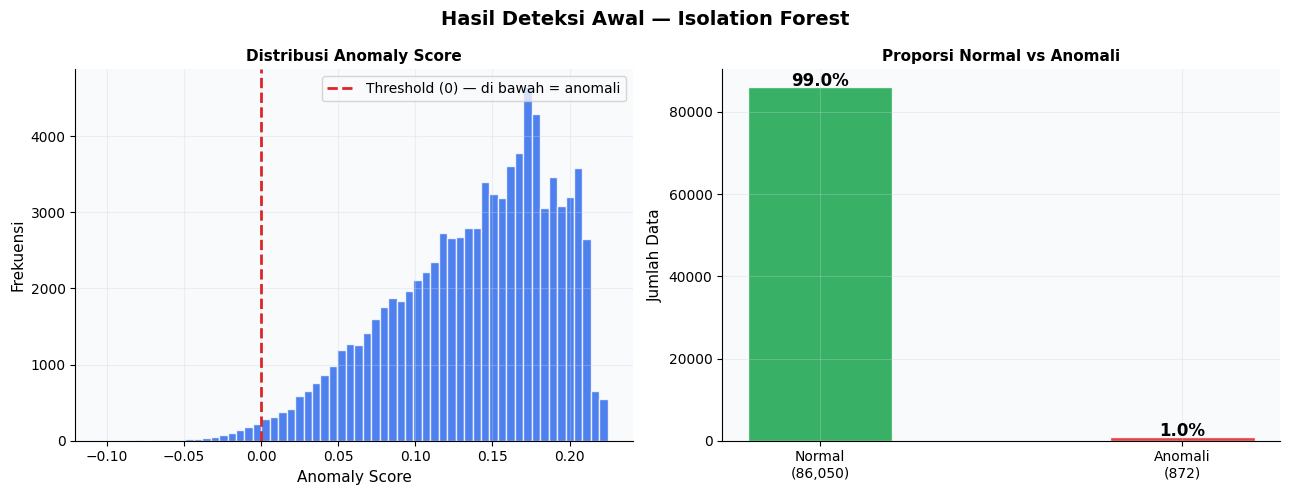

Gambar disimpan: preview_anomaly_detection.png


In [17]:
# Visualisasi anomaly score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hasil Deteksi Awal — Isolation Forest', fontsize=14, fontweight='bold')

# Distribusi anomaly score
axes[0].hist(anomaly_scores, bins=60, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].axvline(0, color=RED, linestyle='--', linewidth=2,
                label='Threshold (0) — di bawah = anomali')
axes[0].set_xlabel('Anomaly Score', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Anomaly Score', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)

# Proporsi normal vs anomali
counts = [n_normal, n_anomaly]
labels = [f'Normal\n({n_normal:,})', f'Anomali\n({n_anomaly:,})']
bars = axes[1].bar(labels, counts, color=[GREEN, RED], alpha=0.85,
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/len(y_pred)*100:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Jumlah Data', fontsize=11)
axes[1].set_title('Proporsi Normal vs Anomali', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('preview_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: preview_anomaly_detection.png')

In [18]:
# contoh reservasi yang terdeteksi sebagai anomali
df_result = df_clean[numerical_features + categorical_features].copy()
df_result['anomaly_label'] = y_pred
df_result['anomaly_score'] = anomaly_scores

anomalies = df_result[df_result['anomaly_label'] == -1].sort_values('anomaly_score')

print(f'10 reservasi dengan anomaly score terendah (paling anomali):')
print(anomalies[['adr','lead_time','total_nights','total_guests',
                 'booking_changes','anomaly_score']].head(10).to_string())

10 reservasi dengan anomaly score terendah (paling anomali):
         adr  lead_time  total_nights  total_guests  booking_changes  anomaly_score
36554  270.0         33             3             2               10      -0.103856
79007    0.0          2             1             1                0      -0.091305
15266    7.0         26             3             1                1      -0.085984
15263    0.0         24            30             1                5      -0.081675
15296    0.0         31             2             2                3      -0.079894
14970    0.0        252             8             2                4      -0.078116
14910  211.2        192            10             3                2      -0.072741
15261    2.4          8             5             1                2      -0.069793
39557  310.0         33             3             4                8      -0.067892
81092    0.0          1             2             2                0      -0.066632


---
## 6. Simpan Dataset Bersih (dataset_clean.csv)

In [19]:
df_clean_save = df_clean[numerical_features + categorical_features].copy()
df_clean_save.to_csv('dataset_clean.csv', index=False)

import os
size_mb = os.path.getsize('dataset_clean.csv') / (1024 * 1024)
print(f'dataset_clean.csv berhasil disimpan!')
print(f'Ukuran file : {size_mb:.2f} MB')
print(f'Shape       : {df_clean_save.shape}')

dataset_clean.csv berhasil disimpan!
Ukuran file : 7.25 MB
Shape       : (86922, 18)


---
##  7. Training Model — Isolation Forest

In [20]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators  = 100,
    contamination = 0.01,
    random_state  = 42
)
iso_forest.fit(X_train)

# 1 = normal, -1 = anomali
iso_pred  = iso_forest.predict(df_scaled)
iso_score = iso_forest.decision_function(df_scaled)

n_iso_anomaly = (iso_pred == -1).sum()
n_iso_normal  = (iso_pred ==  1).sum()

print('=== HASIL ISOLATION FOREST ===')
print(f'Total data  : {len(iso_pred):,}')
print(f'Normal  (1) : {n_iso_normal:,} ({n_iso_normal/len(iso_pred)*100:.2f}%)')
print(f'Anomali (-1): {n_iso_anomaly:,} ({n_iso_anomaly/len(iso_pred)*100:.2f}%)')
print(f'\nAnomaly score rata-rata:')
print(f'  Data normal : {iso_score[iso_pred== 1].mean():.4f}')
print(f'  Data anomali: {iso_score[iso_pred==-1].mean():.4f}')
print(f'  (Semakin rendah = semakin anomali)')

=== HASIL ISOLATION FOREST ===
Total data  : 86,922
Normal  (1) : 86,050 (99.00%)
Anomali (-1): 872 (1.00%)

Anomaly score rata-rata:
  Data normal : 0.1394
  Data anomali: -0.0163
  (Semakin rendah = semakin anomali)


## 8. Training Model — Local Outlier Factor (LOF)

In [21]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors   = 20,
    contamination = 0.01,
    novelty       = True
)
lof.fit(X_train)

lof_pred  = lof.predict(df_scaled)
lof_score = lof.decision_function(df_scaled)

n_lof_anomaly = (lof_pred == -1).sum()
n_lof_normal  = (lof_pred ==  1).sum()

print('=== HASIL LOCAL OUTLIER FACTOR ===')
print(f'Total data  : {len(lof_pred):,}')
print(f'Normal  (1) : {n_lof_normal:,} ({n_lof_normal/len(lof_pred)*100:.2f}%)')
print(f'Anomali (-1): {n_lof_anomaly:,} ({n_lof_anomaly/len(lof_pred)*100:.2f}%)')
print(f'\nAnomaly score rata-rata:')
print(f'  Data normal : {lof_score[lof_pred== 1].mean():.4f}')
print(f'  Data anomali: {lof_score[lof_pred==-1].mean():.4f}')

=== HASIL LOCAL OUTLIER FACTOR ===
Total data  : 86,922
Normal  (1) : 86,144 (99.10%)
Anomali (-1): 778 (0.90%)

Anomaly score rata-rata:
  Data normal : 1.5523
  Data anomali: -1.9826


In [22]:
# menghapus sisa missing value yang terdeteksi setelah proses scaling
df_scaled = df_scaled.dropna()

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    df_scaled,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [24]:
lof.fit(X_train)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 9. Visualisasi Hasil

### Perbandingan Jumlah Anomali & Distribusi Score

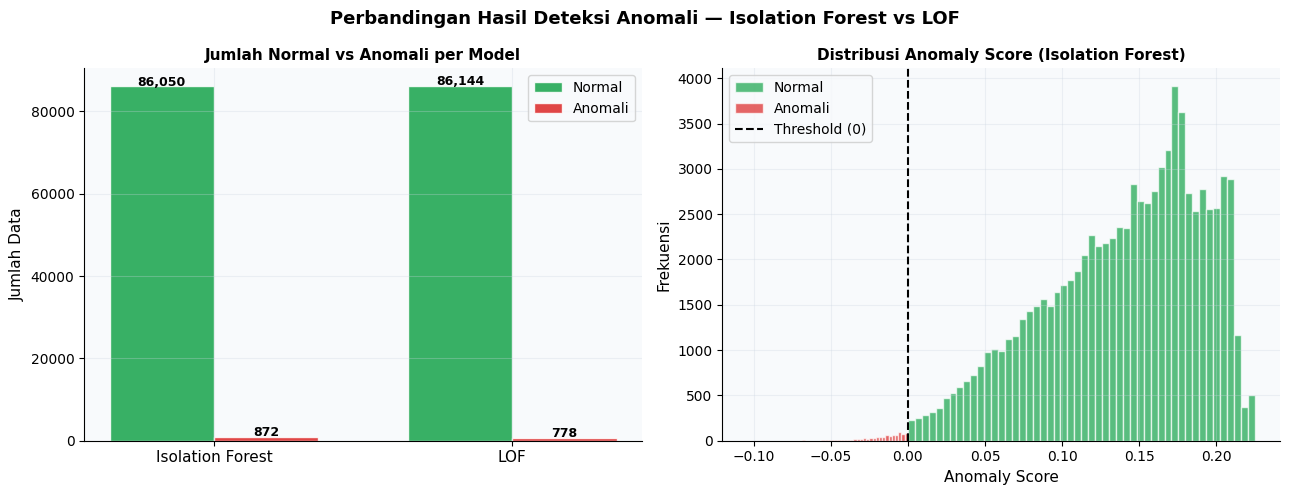

In [25]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Hasil Deteksi Anomali — Isolation Forest vs LOF',
             fontsize=13, fontweight='bold')

# Bar chart perbandingan
models    = ['Isolation Forest', 'LOF']
n_anomaly = [n_iso_anomaly, n_lof_anomaly]
n_normal  = [n_iso_normal,  n_lof_normal]
x         = np.arange(len(models))
width     = 0.35

bars1 = axes[0].bar(x - width/2, n_normal,  width, label='Normal',  color=GREEN, alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + width/2, n_anomaly, width, label='Anomali', color=RED,   alpha=0.85, edgecolor='white')
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{bar.get_height():,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=11)
axes[0].set_ylabel('Jumlah Data', fontsize=11)
axes[0].set_title('Jumlah Normal vs Anomali per Model', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)

# Distribusi anomaly score
axes[1].hist(iso_score[iso_pred== 1], bins=50, color=GREEN, alpha=0.7, label='Normal',  edgecolor='white')
axes[1].hist(iso_score[iso_pred==-1], bins=50, color=RED,   alpha=0.7, label='Anomali', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Threshold (0)')
axes[1].set_xlabel('Anomaly Score', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)
axes[1].set_title('Distribusi Anomaly Score (Isolation Forest)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('hasil_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualisasi Anomali dengan PCA (2D)

Variansi yang dijelaskan PCA:
  PC1   : 9.8%
  PC2   : 7.6%
  Total : 17.4%


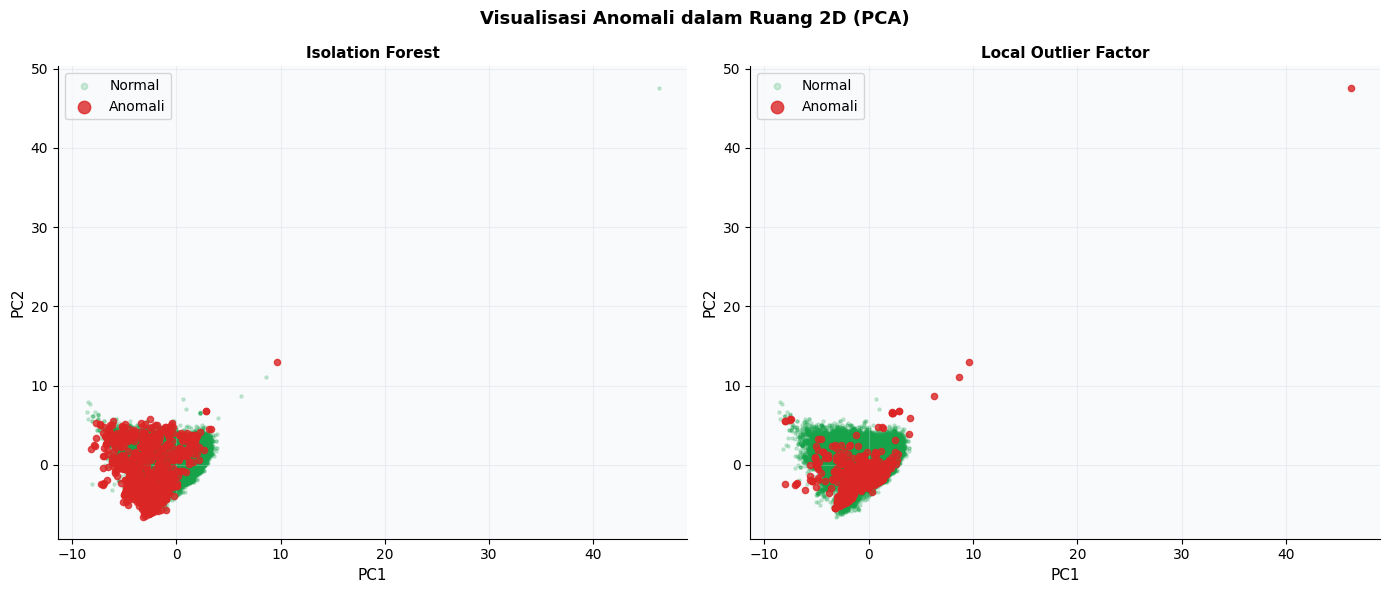

In [26]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_scaled)

print(f'Variansi yang dijelaskan PCA:')
print(f'  PC1   : {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2   : {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total : {sum(pca.explained_variance_ratio_)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Visualisasi Anomali dalam Ruang 2D (PCA)', fontsize=13, fontweight='bold')

for ax, (pred, title) in zip(axes, [
    (iso_pred, 'Isolation Forest'),
    (lof_pred, 'Local Outlier Factor')
]):
    normal_mask  = pred ==  1
    anomaly_mask = pred == -1
    ax.scatter(X_pca[normal_mask,  0], X_pca[normal_mask,  1],
               c=GREEN, alpha=0.2, s=5,  label='Normal')
    ax.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
               c=RED,   alpha=0.8, s=20, label='Anomali', zorder=5)
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, markerscale=2)

plt.tight_layout()
plt.savefig('visualisasi_pca_anomali.png', dpi=150, bbox_inches='tight')
plt.show()

### Profil Fitur — Anomali vs Normal

In [27]:
df_result = df_scaled[numerical_features].copy()
df_result['iso_label'] = iso_pred
df_result['iso_score'] = iso_score

anomalies = df_result[df_result['iso_label'] == -1]
normals   = df_result[df_result['iso_label'] ==  1]

compare = pd.DataFrame({
    'Normal (rata-rata)' : normals[numerical_features].mean().round(2),
    'Anomali (rata-rata)': anomalies[numerical_features].mean().round(2),
})
compare['Selisih']       = (compare['Anomali (rata-rata)'] - compare['Normal (rata-rata)']).round(2)
compare['Keterangan']    = compare['Selisih'].apply(
    lambda x: '↑ Anomali lebih tinggi' if x > 0 else '↓ Anomali lebih rendah'
)
print('Perbandingan rata-rata fitur: Normal vs Anomali')
print(compare.to_string())

Perbandingan rata-rata fitur: Normal vs Anomali
                             Normal (rata-rata)  Anomali (rata-rata)  Selisih              Keterangan
lead_time                                  0.00                -0.08    -0.08  ↓ Anomali lebih rendah
adr                                        0.00                -0.48    -0.48  ↓ Anomali lebih rendah
total_nights                               0.00                -0.03    -0.03  ↓ Anomali lebih rendah
total_guests                               0.00                -0.49    -0.49  ↓ Anomali lebih rendah
adr_per_guest                              0.00                -0.12    -0.12  ↓ Anomali lebih rendah
total_of_special_requests                 -0.00                 0.39     0.39  ↑ Anomali lebih tinggi
booking_changes                           -0.01                 1.16     1.17  ↑ Anomali lebih tinggi
previous_cancellations                    -0.03                 2.71     2.74  ↑ Anomali lebih tinggi
days_in_waiting_list              

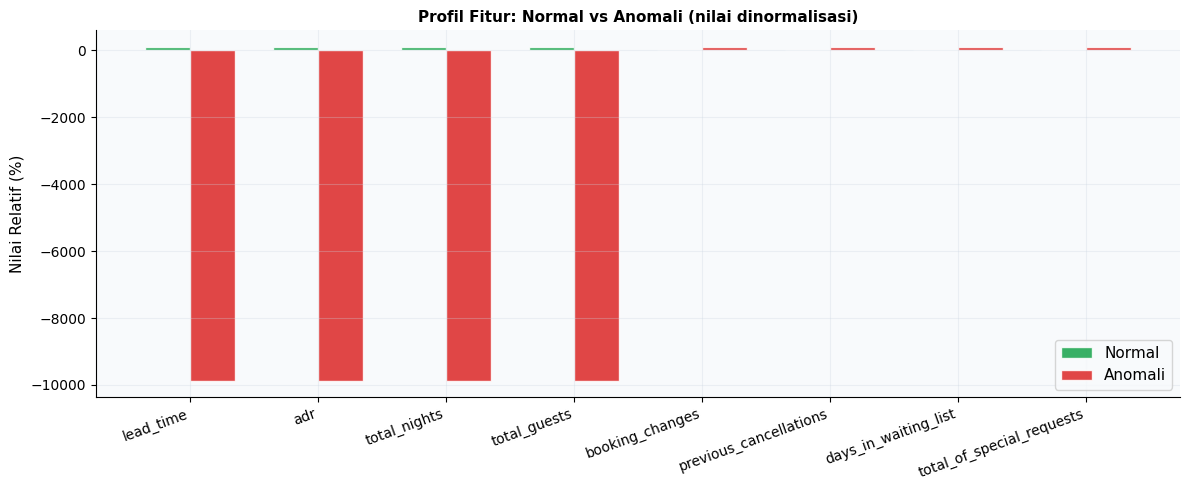

In [28]:
features_plot   = ['lead_time','adr','total_nights','total_guests',
                   'booking_changes','previous_cancellations',
                   'days_in_waiting_list','total_of_special_requests']
val_normal      = normals[features_plot].mean().values
val_anomaly     = anomalies[features_plot].mean().values
max_vals        = np.maximum(val_normal, val_anomaly)
max_vals[max_vals == 0] = 1
val_normal_norm  = val_normal  / max_vals * 100
val_anomaly_norm = val_anomaly / max_vals * 100

x     = np.arange(len(features_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, val_normal_norm,  width, label='Normal',  color=GREEN, alpha=0.85, edgecolor='white')
ax.bar(x + width/2, val_anomaly_norm, width, label='Anomali', color=RED,   alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(features_plot, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Nilai Relatif (%)', fontsize=11)
ax.set_title('Profil Fitur: Normal vs Anomali (nilai dinormalisasi)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('profil_anomali_vs_normal.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Contoh Reservasi Anomali & Kategorisasi

In [29]:
# reservasi paling anomali
top_anomalies = df_result[df_result['iso_label'] == -1].sort_values('iso_score').head(15)
cols_show     = ['adr','lead_time','total_nights','total_guests',
                 'booking_changes','previous_cancellations','days_in_waiting_list','iso_score']
print('15 Reservasi Paling Anomali:')
print(top_anomalies[cols_show].to_string())

15 Reservasi Paling Anomali:
            adr  lead_time  total_nights  total_guests  booking_changes  previous_cancellations  days_in_waiting_list  iso_score
30428  2.971130  -0.545521     -0.230472     -0.033456        13.348899               -0.081946             -0.074269  -0.103856
54346 -1.934423  -0.906123     -0.954695     -1.291253        -0.374398                5.326514             -0.074269  -0.091305
11662 -1.807242  -0.626947     -0.230472     -1.291253         0.997932                2.622284             -0.074269  -0.085984
11659 -1.934423  -0.650212      9.546537     -1.291253         6.487251               -0.081946             -0.074269  -0.081675
11692 -1.934423  -0.568785     -0.592583     -0.033456         3.742591               -0.081946             -0.074269  -0.079894
11509 -1.934423   2.001956      1.580085     -0.033456         5.114921               -0.081946             -0.074269  -0.078116
11449  1.902810   1.304017      2.304308      1.224342         2.370

Distribusi Jenis Anomali:
jenis_anomali
ADR Negatif/Nol              687
Kombinasi Pola Janggal       174
Riwayat Batal Tinggi           8
Perubahan Booking Ekstrem      3


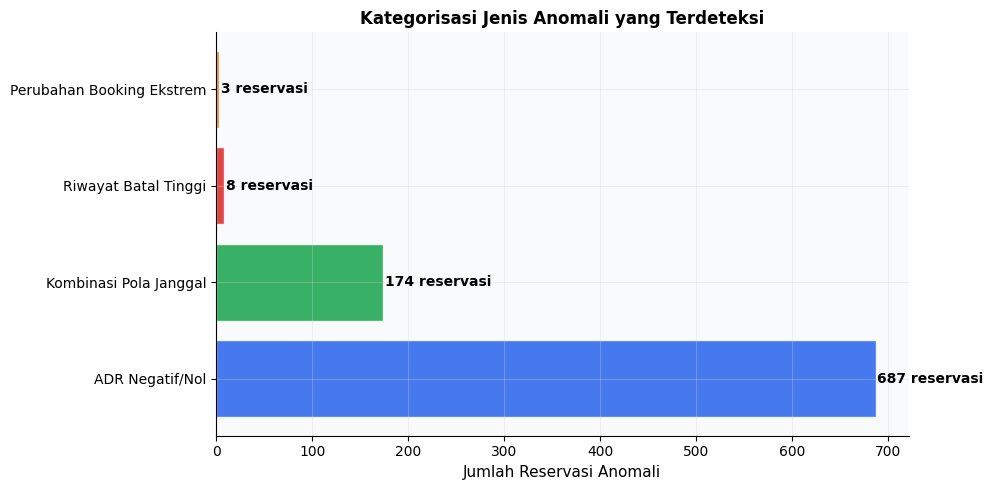

In [30]:
# Kategorisasi jenis anomali
df_anomaly_detail = df_scaled[numerical_features].copy()
df_anomaly_detail['iso_label'] = iso_pred
df_anomaly_detail              = df_anomaly_detail[df_anomaly_detail['iso_label'] == -1].copy()

def kategorisasi_anomali(row):
    if row['adr'] <= 0:
        return 'ADR Negatif/Nol'
    elif row['adr'] > 500:
        return 'ADR Ekstrem Tinggi'
    elif row['total_guests'] == 0:
        return 'Tanpa Tamu'
    elif row['previous_cancellations'] > 5:
        return 'Riwayat Batal Tinggi'
    elif row['days_in_waiting_list'] > 100:
        return 'Waitlist Sangat Panjang'
    elif row['booking_changes'] > 10:
        return 'Perubahan Booking Ekstrem'
    elif row['lead_time'] > 500:
        return 'Lead Time Ekstrem'
    else:
        return 'Kombinasi Pola Janggal'

df_anomaly_detail['jenis_anomali'] = df_anomaly_detail.apply(kategorisasi_anomali, axis=1)
jenis_count = df_anomaly_detail['jenis_anomali'].value_counts()

print('Distribusi Jenis Anomali:')
print(jenis_count.to_string())

# Visualisasi
colors_bar = [BLUE, GREEN, RED, AMBER, PURPLE, GRAY, '#EC4899']
fig, ax    = plt.subplots(figsize=(10, 5))
bars       = ax.barh(jenis_count.index, jenis_count.values,
                     color=colors_bar[:len(jenis_count)], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, jenis_count.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val} reservasi', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Jumlah Reservasi Anomali', fontsize=11)
ax.set_title('Kategorisasi Jenis Anomali yang Terdeteksi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('kategorisasi_anomali.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Perbandingan Model — Isolation Forest vs LOF

In [31]:
both_anomaly = ((iso_pred == -1) & (lof_pred == -1)).sum()
only_iso     = ((iso_pred == -1) & (lof_pred ==  1)).sum()
only_lof     = ((iso_pred ==  1) & (lof_pred == -1)).sum()
both_normal  = ((iso_pred ==  1) & (lof_pred ==  1)).sum()

print('=== PERBANDINGAN ISOLATION FOREST vs LOF ===')
print(f'\n{"Metrik":<40} {"Isolation Forest":>18} {"LOF":>10}')
print('-' * 70)
print(f'{"Jumlah anomali":<40} {n_iso_anomaly:>18,} {n_lof_anomaly:>10,}')
print(f'{"Persentase anomali":<40} {n_iso_anomaly/len(iso_pred)*100:>17.2f}% {n_lof_anomaly/len(lof_pred)*100:>9.2f}%')
print()
print(f'Anomali disepakati KEDUA model      : {both_anomaly:,} reservasi')
print(f'Anomali hanya Isolation Forest      : {only_iso:,} reservasi')
print(f'Anomali hanya LOF                   : {only_lof:,} reservasi')
print(f'Normal menurut KEDUA model          : {both_normal:,} reservasi')
print()
print('Interpretasi: Anomali yang disepakati kedua model memiliki')
print('tingkat kepercayaan lebih tinggi untuk ditindaklanjuti.')

=== PERBANDINGAN ISOLATION FOREST vs LOF ===

Metrik                                     Isolation Forest        LOF
----------------------------------------------------------------------
Jumlah anomali                                          872        778
Persentase anomali                                    1.00%      0.90%

Anomali disepakati KEDUA model      : 32 reservasi
Anomali hanya Isolation Forest      : 840 reservasi
Anomali hanya LOF                   : 746 reservasi
Normal menurut KEDUA model          : 85,304 reservasi

Interpretasi: Anomali yang disepakati kedua model memiliki
tingkat kepercayaan lebih tinggi untuk ditindaklanjuti.


## 12. Interpretasi Bisnis

| Jenis Anomali | Kemungkinan Penyebab | Rekomendasi |
|---|---|---|
| ADR Negatif/Nol | Error sistem pencatatan | Verifikasi manual ke sistem pembayaran |
| ADR Ekstrem Tinggi | Suite premium atau event khusus | Konfirmasi ulang dengan tim revenue |
| Tanpa Tamu | Bug sistem atau test entry | Investigasi dan hapus jika tidak valid |
| Riwayat Batal Tinggi | Potensi fraud atau tamu tidak serius | Terapkan kebijakan deposit ketat |
| Waitlist Sangat Panjang | Error sistem waitlist | Review dan bersihkan data waitlist |
| Perubahan Booking Ekstrem | Ketidakpastian rencana tamu | Hubungi tamu untuk konfirmasi |
| Kombinasi Pola Janggal | Berbagai faktor bersamaan | Flag untuk review manual tim operasional |

---
Tabel  perbandingan
| Aspek | Isolation Forest | LOF |
|---|---|---|
| Jumlah anomali | 872 (1,00%) | 778 (0,90%) |
| Kecepatan training | Cepat | Lebih lambat |
| Cara kerja | Berbasis tree — isolasi data | Berbasis densitas — bandingkan tetangga |
| Keunggulan | Efisien untuk data besar | Lebih sensitif terhadap anomali lokal |
| Anomali disepakati berdua | ✓ Data yang dianggap anomali oleh keduanya lebih dapat dipercaya |

**Kesimpulan:** Isolation Forest dipilih sebagai model utama karena lebih efisien untuk dataset besar dan hasilnya konsisten. Anomali yang disepakati kedua model sekaligus memiliki tingkat kepercayaan lebih tinggi untuk ditindaklanjuti oleh manajemen hotel.